# Run the 9-balancing-area model

Choose `RUN_MODE`, edit the settings relevant to that mode, then run all cells.

- `daily`: runs the date in `REFERENCE_DATE` (24 hours).
- `monthly`: runs every day in the month containing `REFERENCE_DATE`. To keep unit commitment tractable, each day is solved independently.
- `peak`: runs one continuous 168-hour unit-commitment problem for the week containing the annual peak demand. `REFERENCE_DATE` is ignored.
- `selected_weeks`: runs each date in `WEEK_STARTS` as an independent continuous seven-day problem, with configurable warm-up and look-ahead days.
- `rolling`: runs the full 8,760-hour year as rolling windows. Each solve optimizes seven committed days plus one look-ahead day, carries commitment/dispatch/storage state forward, and checkpoints every completed week. `REFERENCE_DATE` is ignored.

Gas and nuclear daily energy are equality constrained in every mode. Results are saved automatically under `9_BA/run_results/`. Rolling mode resumes existing completed checkpoints when `RESUME = True`.

After a rolling run, use `9BA_results_analysis_rolling_year.ipynb` for the full-year analysis, including wind-resource and hydro-utilization seasonality against observed FY2025-26 generation.

In [4]:
# ===================== USER SETTINGS =====================
RUN_MODE = "selected_weeks"   # "daily", "monthly", "peak", "selected_weeks", or "rolling"
REFERENCE_DATE = "2025-07-11"  # day; month is inferred; ignored for peak/selected_weeks/rolling
WEEK_STARTS = [
    "2025-04-07",  # dry / low hydro
    "2025-07-07",  # southwest-monsoon wind and hydro peak
    "2025-10-13",  # monsoon transition
    "2026-02-16",  # dry-season low renewables
]
WARMUP_DAYS = 1
LOOKAHEAD_DAYS = 1
RESERVOIR_INITIAL_SOC_FRACTION = 0.0  # independent-week assumption; test sensitivity if needed
SOLVER_NAME = "highs"
MIP_REL_GAP = 0.05            # 1% gap; increase for a faster approximate solve
RESUME = False                  # selected_weeks/rolling: reuse compatible completed solves
# =========================================================

In [5]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "scripts").exists():
    ROOT = ROOT.parent
if not (ROOT / "scripts").exists():
    raise FileNotFoundError("Run this notebook from the repository or the 9_BA folder.")

sys.path.insert(0, str(ROOT / "scripts"))
from run_9ba_selection import run_selection

result = run_selection(
    RUN_MODE,
    REFERENCE_DATE,
    week_starts=WEEK_STARTS,
    warmup_days=WARMUP_DAYS,
    lookahead_days=LOOKAHEAD_DAYS,
    reservoir_initial_soc_fraction=RESERVOIR_INITIAL_SOC_FRACTION,
    solver_name=SOLVER_NAME,
    mip_rel_gap=MIP_REL_GAP,
    resume=RESUME,
)

Loading C:\Users\b076218\Documents\Filkassen\DEA_GE_github\PyPSA-TamilNadu\9_BA\model ...
Loaded network from cached copy in 0.03 s.
Solving selected week 1/4: 2025-04-07 to 2025-04-13 (1 warm-up + 7 retained + 1 look-ahead days)


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - mip_rel_gap: 0.05
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing binary variables.: 100%|██████████| 3/3 [00:00<00:00, 342.57it/s]
INFO:linopy.io: Writing time: 0.87s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 214704 primals, 658539 duals
Objective: 6.87e+09
Solver: highs
Runtime: 1602.43s
MIP gap: 7.95e-04
Dual bound: 6.86e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-status-p-fixed-upper, Generator-start_up-p-fixed-upper, Generator-shut_down-p-fixed-upper, Generator-fix-p-lower, Generator-fix-p-upper, Generator-com-p-lower, Generator-com-p-upper, Generator-com-transition-start-up, Generator-com-transition-shut-down, Generator-com-up-time, Generator-com-down-time, Generator-com-status-min_down_time_must_stay_up, Generator-p-ramp_limit_

Solving selected week 2/4: 2025-07-07 to 2025-07-13 (1 warm-up + 7 retained + 1 look-ahead days)


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - mip_rel_gap: 0.05
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing binary variables.: 100%|██████████| 3/3 [00:00<00:00, 289.03it/s]
INFO:linopy.io: Writing time: 0.69s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 214704 primals, 658539 duals
Objective: 4.43e+09
Solver: highs
Runtime: 1840.16s
MIP gap: 5.48e-03
Dual bound: 4.40e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-status-p-fixed-upper, Generator-start_up-p-fixed-upper, Generator-shut_down-p-fixed-upper, Generator-fix-p-lower, Generator-fix-p-upper, Generator-com-p-lower, Generator-com-p-upper, Generator-com-transition-start-up, Generator-com-transition-shut-down, Generator-com-up-time, Generator-com-down-time, Generator-com-status-min_down_time_must_stay_up, Generator-p-ramp_limit_

Solving selected week 3/4: 2025-10-13 to 2025-10-19 (1 warm-up + 7 retained + 1 look-ahead days)


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - mip_rel_gap: 0.05
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing binary variables.: 100%|██████████| 3/3 [00:00<00:00, 333.01it/s]
INFO:linopy.io: Writing time: 0.6s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 214704 primals, 658539 duals
Objective: 6.22e+09
Solver: highs
Runtime: 1986.68s
MIP gap: 1.53e-03
Dual bound: 6.21e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-status-p-fixed-upper, Generator-start_up-p-fixed-upper, Generator-shut_down-p-fixed-upper, Generator-fix-p-lower, Generator-fix-p-upper, Generator-com-p-lower, Generator-com-p-upper, Generator-com-transition-start-up, Generator-com-transition-shut-down, Generator-com-up-time, Generator-com-down-time, Generator-com-status-min_down_time_must_stay_up, Generator-p-ramp_limit_u

Solving selected week 4/4: 2026-02-16 to 2026-02-22 (1 warm-up + 7 retained + 1 look-ahead days)


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - mip_rel_gap: 0.05
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing binary variables.: 100%|██████████| 3/3 [00:00<00:00, 285.40it/s]
INFO:linopy.io: Writing time: 0.61s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 214704 primals, 658539 duals
Objective: 5.66e+09
Solver: highs
Runtime: 1117.98s
MIP gap: 1.33e-02
Dual bound: 5.59e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-status-p-fixed-upper, Generator-start_up-p-fixed-upper, Generator-shut_down-p-fixed-upper, Generator-fix-p-lower, Generator-fix-p-upper, Generator-com-p-lower, Generator-com-p-upper, Generator-com-transition-start-up, Generator-com-transition-shut-down, Generator-com-up-time, Generator-com-down-time, Generator-com-status-min_down_time_must_stay_up, Generator-p-ramp_limit_

Finished. Results: C:\Users\b076218\Documents\Filkassen\DEA_GE_github\PyPSA-TamilNadu\9_BA\run_results\selected_weeks


Mode: selected_weeks
Period: 2025-04-07 to 2026-02-22
Saved to: C:\Users\b076218\Documents\Filkassen\DEA_GE_github\PyPSA-TamilNadu\9_BA\run_results\selected_weeks
Per-week results:
  C:\Users\b076218\Documents\Filkassen\DEA_GE_github\PyPSA-TamilNadu\9_BA\run_results\selected_weeks\week_2025-04-07
  C:\Users\b076218\Documents\Filkassen\DEA_GE_github\PyPSA-TamilNadu\9_BA\run_results\selected_weeks\week_2025-07-07
  C:\Users\b076218\Documents\Filkassen\DEA_GE_github\PyPSA-TamilNadu\9_BA\run_results\selected_weeks\week_2025-10-13
  C:\Users\b076218\Documents\Filkassen\DEA_GE_github\PyPSA-TamilNadu\9_BA\run_results\selected_weeks\week_2026-02-16


,modeled_gwh,observed_gwh,difference_gwh,difference_pct
carrier,,,,
coal,5405.125,5177.31,227.815,4.400
oil_gas,101.060,101.06,0.000,0.000
nuclear,1480.890,1480.89,0.000,0.000
hydro,379.578,380.00,-0.422,-0.111
solar,1798.233,1036.00,762.233,73.575
wind,1327.139,1463.70,-136.561,-9.330
comparable_total,10492.025,9638.96,853.065,8.850


,value
formulation,independent continuous selected weeks
weeks_solved,4
days_retained,28
warmup_days_per_week,1
lookahead_days_per_week,1
reservoir_initial_soc_fraction,0.0
all_solver_statuses_ok,True
max_abs_gas_target_deviation_mwh,0.0
max_abs_nuclear_target_deviation_mwh,0.0
max_abs_nodal_residual_mw,0.0


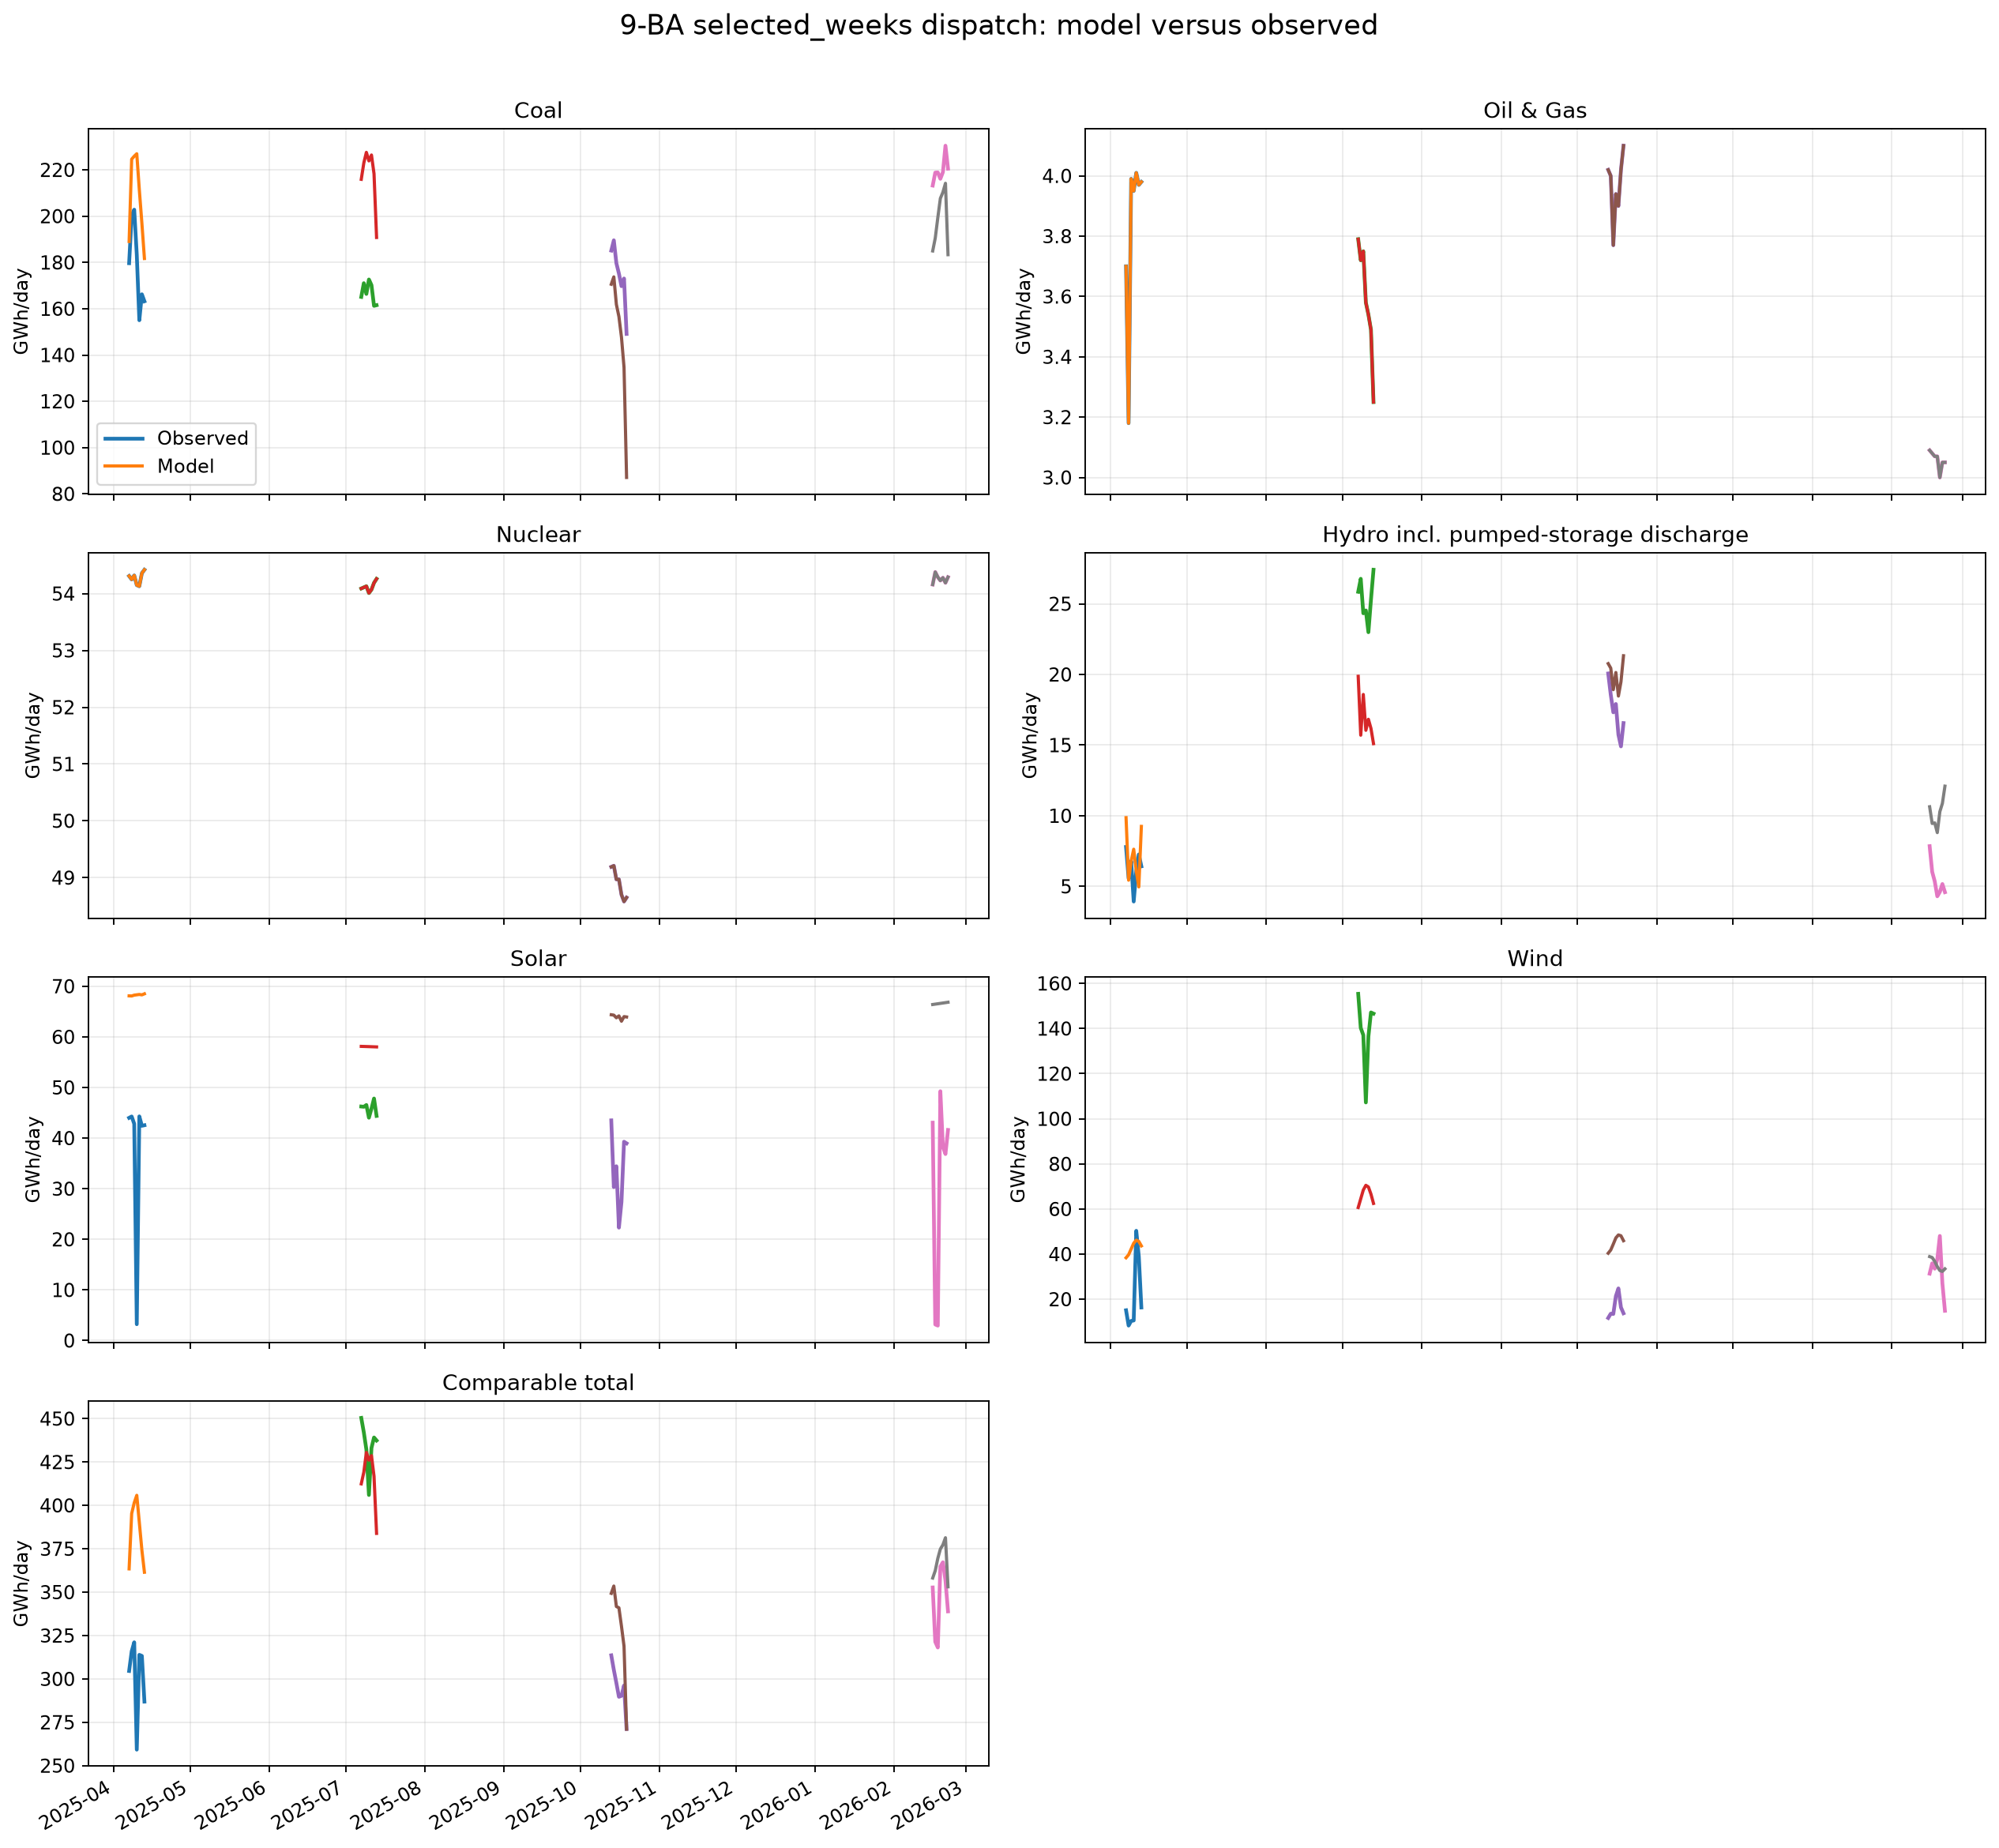

In [3]:
from IPython.display import Image, display
import pandas as pd

print(f"Mode: {result['mode']}")
print(f"Period: {result['dates'][0].date()} to {result['dates'][-1].date()}")
print(f"Saved to: {result['output_dir']}")
if result.get('week_dirs'):
    print('Per-week results:')
    for path in result['week_dirs']:
        print(f'  {path}')
display(result["summary"].round(3))
display(pd.Series(result["validation"], name="value").to_frame())
display(Image(filename=str(result["plot_path"])))